In [18]:
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
#Connect to MySQL Database
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="priya13",
    database="retail_db"
)

In [21]:
#Load Data from MySQL
query = "SELECT * FROM retail_sales"
df = pd.read_sql(query, connection)
df

C:\Users\Welcome\AppData\Local\Temp\ipykernel_18200\3088917655.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,order_id,order_date,region,category,sub_category,product_name,sales,quantity,profit,inventory_days
0,101,2024-01-05,East,Furniture,Chair,Office Chair,2500.0,5,300.0,20
1,102,2024-01-10,West,Technology,Laptop,Dell Laptop,55000.0,2,5000.0,15
2,103,2024-02-02,South,Office Supplies,Paper,A4 Sheets,800.0,20,120.0,30
3,104,2024-02-12,North,Furniture,Table,Study Table,4500.0,3,600.0,18
4,105,2024-03-01,East,Technology,Phone,Samsung Mobile,30000.0,4,3500.0,12


In [22]:
df.head()

,order_id,order_date,region,category,sub_category,product_name,sales,quantity,profit,inventory_days
0,101,2024-01-05,East,Furniture,Chair,Office Chair,2500.0,5,300.0,20
1,102,2024-01-10,West,Technology,Laptop,Dell Laptop,55000.0,2,5000.0,15
2,103,2024-02-02,South,Office Supplies,Paper,A4 Sheets,800.0,20,120.0,30
3,104,2024-02-12,North,Furniture,Table,Study Table,4500.0,3,600.0,18
4,105,2024-03-01,East,Technology,Phone,Samsung Mobile,30000.0,4,3500.0,12


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        5 non-null      int64  
 1   order_date      5 non-null      object 
 2   region          5 non-null      object 
 3   category        5 non-null      object 
 4   sub_category    5 non-null      object 
 5   product_name    5 non-null      object 
 6   sales           5 non-null      float64
 7   quantity        5 non-null      int64  
 8   profit          5 non-null      float64
 9   inventory_days  5 non-null      int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 532.0+ bytes


In [24]:
df.describe()


,order_id,sales,quantity,profit,inventory_days
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,103.000000,18560.000000,6.800000,1904.000000,19.000000
std,1.581139,23610.230833,7.463243,2212.934703,6.855655
min,101.000000,800.000000,2.000000,120.000000,12.000000
25%,102.000000,2500.000000,3.000000,300.000000,15.000000
50%,103.000000,4500.000000,4.000000,600.000000,18.000000
75%,104.000000,30000.000000,5.000000,3500.000000,20.000000
max,105.000000,55000.000000,20.000000,5000.000000,30.000000


In [25]:
#Convert Date Column
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month

In [26]:
#Profit by Category
category_profit = df.groupby('category')[['sales','profit']].sum()
category_profit['profit_margin'] = (category_profit['profit'] / category_profit['sales']) * 100
category_profit

,sales,profit,profit_margin
category,,,
Furniture,7000.0,900.0,12.857143
Office Supplies,800.0,120.0,15.000000
Technology,85000.0,8500.0,10.000000


In [27]:
#Profit by Sub-Category
sub_profit = df.groupby('sub_category')[['sales','profit']].sum()
sub_profit['profit_margin'] = (sub_profit['profit'] / sub_profit['sales']) * 100
sub_profit

,sales,profit,profit_margin
sub_category,,,
Chair,2500.0,300.0,12.000000
Laptop,55000.0,5000.0,9.090909
Paper,800.0,120.0,15.000000
Phone,30000.0,3500.0,11.666667
Table,4500.0,600.0,13.333333


In [28]:
#Correlation Between Inventory Days and Profit
df[['inventory_days','profit']].corr()

,inventory_days,profit
inventory_days,1.000000,-0.716493
profit,-0.716493,1.000000


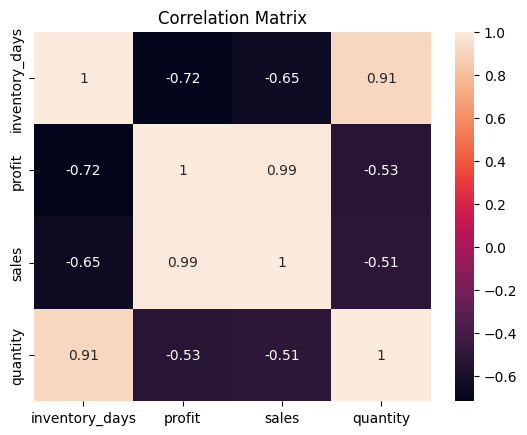

In [29]:
#Correlation Heatmap
sns.heatmap(df[['inventory_days','profit','sales','quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

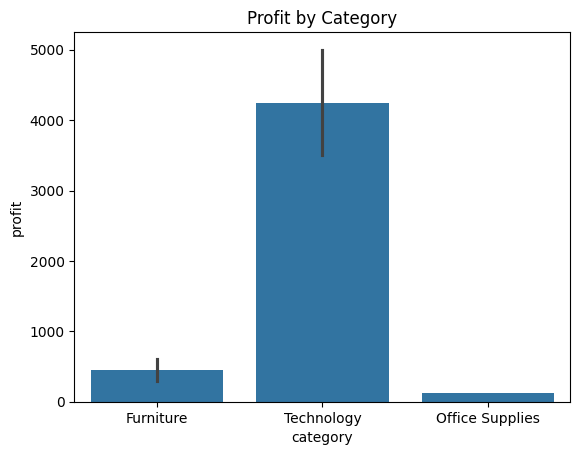

In [30]:
#Profit by Category Chart
sns.barplot(x='category', y='profit', data=df)
plt.title("Profit by Category")
plt.show()

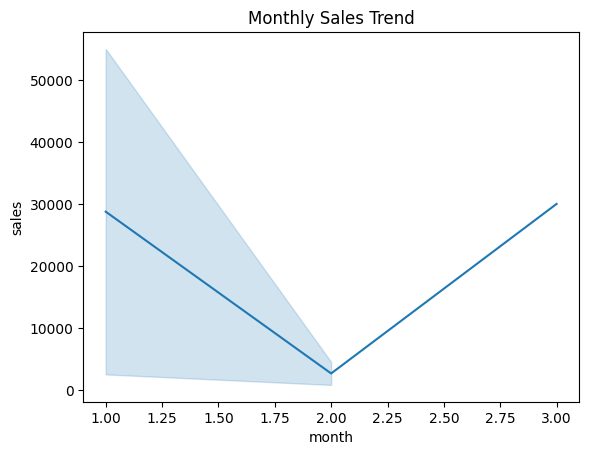

In [31]:
sns.lineplot(x='month', y='sales', data=df)
plt.title("Monthly Sales Trend")
plt.show()

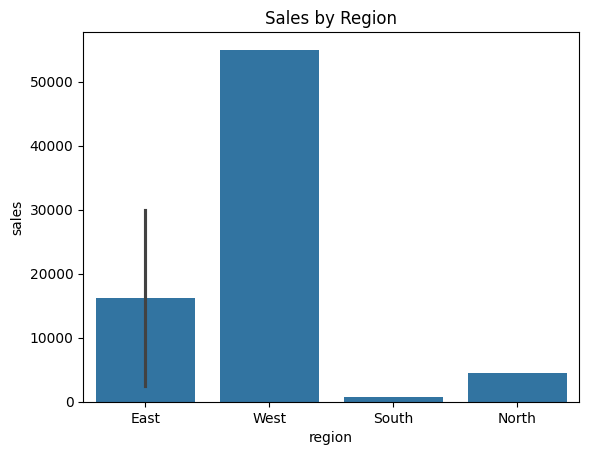

In [32]:
#Sales by Region
sns.barplot(x='region', y='sales', data=df)
plt.title("Sales by Region")
plt.show()

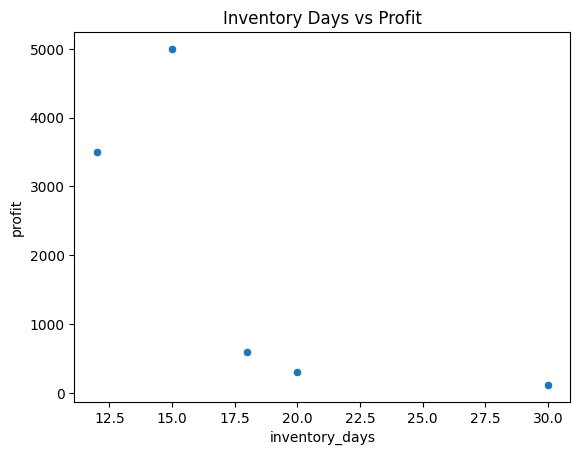

In [33]:
sns.scatterplot(x='inventory_days', y='profit', data=df)
plt.title("Inventory Days vs Profit")
plt.show()